# IDS 570: TEXT AS DATA | TERM PROJECT (OPTION A) REPORT 

For: Prof. Astrid Adele Giugni, Duke University 

By: Varun Sen Bahl - April 24, 2026

#### About this notebook

_This Jupyter Notebook accompanies the main term project report available [here]()._

#### Table of Contents 

1. [Setup and Data Preparation](#1-setup-and-data-preparation)

2. [Data and Concept Analysis](#2-data-and-concept-analysis)

3. [Named Entity Recognition (NER) Analysis](#3-named-entity-recognition)

4. [Contextual Meaning Analysis (BERT)](#4-contextual-meaning-with-bert)

5. [Supervised Classification (Logistic Regression)](#5-supervised-classification-logistic-regression)

6. [Synthesis and Interpretation](#6-synthesis)


#### 1. Setup and Data Preparation 

In [44]:
# Required packages
"""
%%!pip install -q numpy pandas matplotlib seaborn tqdm ipykernel black spacy transformers torch sentence-transformers umap-learn scikit-learn nltk
!python -m spacy download en_core_web_sm

"""
# import sys
# print(sys.executable)

'\n%%!pip install -q numpy pandas matplotlib seaborn tqdm ipykernel black spacy transformers torch sentence-transformers umap-learn scikit-learn nltk\n!python -m spacy download en_core_web_sm\n\n'

In [111]:
# Load packages - setup
import re, string, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import sent_tokenize

# load packages - analysis
import spacy
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModel
import torch
import warnings

warnings.filterwarnings("ignore")

/Users/varun/Documents/Duke-Astrid/Homework/term-project/.ids570/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
# set up nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

In [47]:
# Base directories
BASE_DIR = Path.cwd()

# Subdirectories
TEXT_DIR = BASE_DIR / "texts"
OUTPUTS = BASE_DIR / "outputs"
OUTPUT_CSV = OUTPUTS / "money_occurrences.csv"
OUTPUT_CHART = OUTPUTS / "money_distribution_top50.png"

In [48]:
# creating dataframe for texts
records = []

for path in TEXT_DIR.glob("*.txt"):
    text = path.read_text(encoding="utf-8", errors="ignore")
    file_name = path.name
    records.append({"doc_id": file_name, "text": text})

docs = pd.DataFrame(records)

In [49]:
# basic cleaning of texts
def clean_text(text):
    text = text.replace("ſ", "s")
    text = text.replace("●", "")
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


docs["text_clean"] = docs["text"].apply(clean_text)

In [50]:
# concept pattern
MONEY_PATTERN = re.compile(r"\b(money|mony|moneys|monies)\b", re.IGNORECASE)

#### 2. Data and Concept Analysis 

In [51]:
# getting sentence window
def get_sentence_window(text, match_start, window=2):
    sentences = sent_tokenize(text)

    char_count = 0

    for i, sentence in enumerate(sentences):
        sentence_start = char_count
        sentence_end = char_count + len(sentence)

        if sentence_start <= match_start <= sentence_end:
            start = max(0, i - window)
            end = min(len(sentences), i + window + 1)
            return " ".join(sentences[start:end]).strip()

        char_count += len(sentence) + 1

    return ""

In [ ]:
# search for money in pattern
money_occurrences = []
file_counts = {}

for _, row in docs.iterrows():
    filename = row["doc_id"]
    text = row["text_clean"]

    sentences = sent_tokenize(text)

    spans = []
    char_count = 0

    for sentence in sentences:
        start = char_count
        end = char_count + len(sentence)
        spans.append((start, end))
        char_count = end + 1

    matches = list(MONEY_PATTERN.finditer(text))
    file_counts[filename] = len(matches)

    for match in matches:
        matched_word = match.group()
        match_pos = match.start()

        sentence_window = ""

        for i, (start, end) in enumerate(spans):
            if start <= match_pos <= end:
                window_start = max(0, i - 2)
                window_end = min(len(sentences), i + 3)

                sentence_window = " ".join(sentences[window_start:window_end])
                break

        money_occurrences.append(
            {
                "doc_id": filename,
                "matched_word": matched_word,
                "sentence_window": sentence_window,
            }
        )

money_occurrences = pd.DataFrame(money_occurrences)

total_matches = len(money_occurrences)
files_with_matches = sum(1 for count in file_counts.values() if count > 0)

print("=" * 60)
print(f"TOTAL occurrences of money / moneys / monies: {total_matches}")
print(f"Files containing at least one match: {files_with_matches} / {len(docs)}")
print("=" * 60)

TOTAL occurrences of money / moneys / monies: 15592
Files containing at least one match: 440 / 571


In [ ]:
money_occurrences.to_csv(
    OUTPUT_CSV, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL
)

In [ ]:
# identify top 50 files
sorted_files = sorted(file_counts.items(), key=lambda x: x[1], reverse=True)

print("\nTop 50 files by number of 'money' occurrences:")
for fname, count in sorted_files[:50]:
    print(f"  {fname}: {count}")

    with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["filename", "matched_word", "sentence_window"])
        writer.writerows(money_occurrences)

    print(f"\nResults saved to: {OUTPUT_CSV}")

    files_to_plot = [(f, c) for f, c in sorted_files if c > 0][:50]

    names = [f.replace(".txt", "") for f, c in files_to_plot]
    counts = [c for f, c in files_to_plot]


Top 50 files by number of 'money' occurrences:
  A06786.txt: 1247

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  Wealth_Nations.txt: 774

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A71307.txt: 568

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A07834.txt: 498

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A68617.txt: 430

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A16053.txt: 425

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A10821.txt: 418

Results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv
  A06785.txt: 392

Results saved to: /Users/varun/Documents/Duke-Astrid/Hom

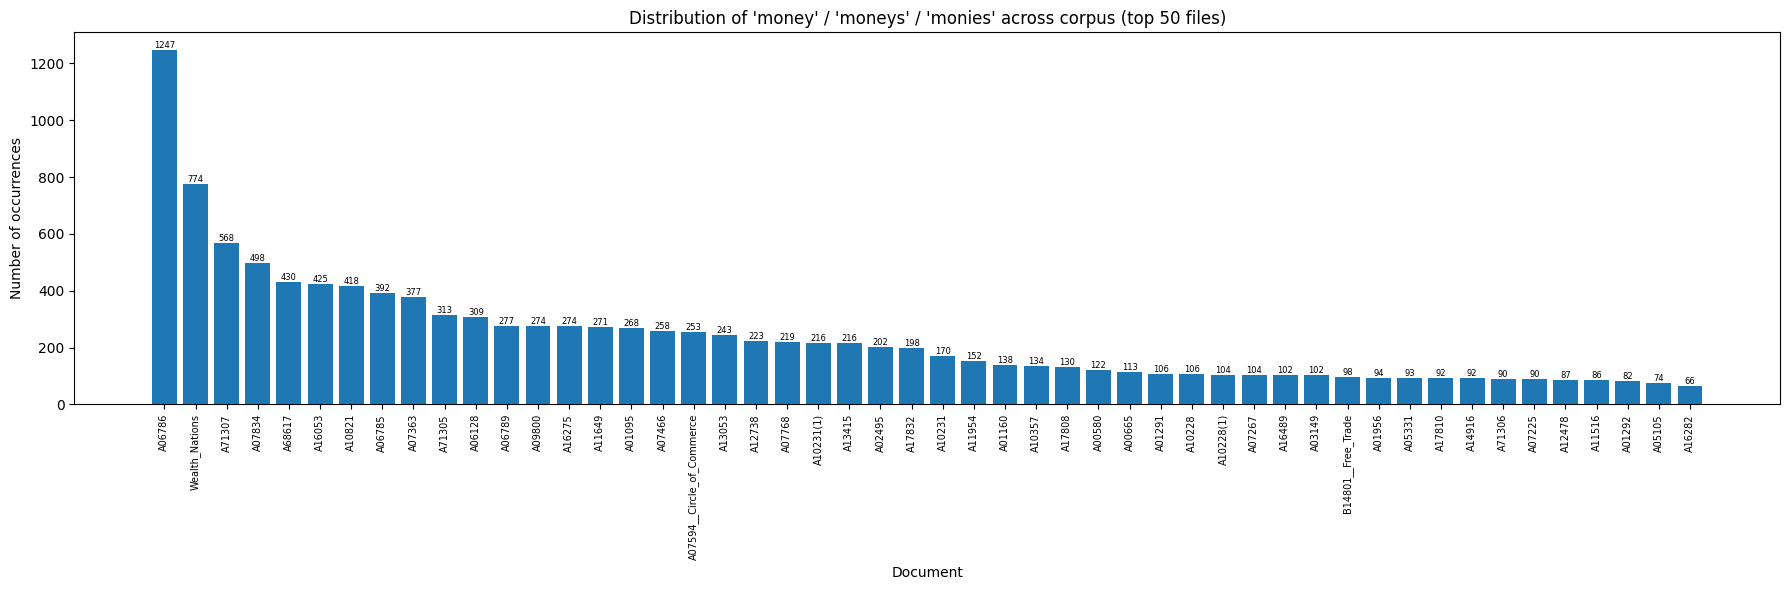

Chart saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_distribution_top50.png


In [56]:
# chart containing outputs

plt.figure(figsize=(18, 6))
bars = plt.bar(names, counts, color="steelblue")
plt.bar(names, counts)

plt.xticks(rotation=90, fontsize=7)
plt.xlabel("Document")
plt.ylabel("Number of occurrences")
plt.title("Distribution of 'money' / 'moneys' / 'monies' across corpus (top 50 files)")
plt.bar_label(bars, fontsize=6)

plt.tight_layout()
plt.savefig(OUTPUT_CHART)
plt.show()

print(f"Chart saved to: {OUTPUT_CHART}")

#### 3. Named Entity Recognition 

In [91]:
# setting up files
NER_OUTPUT = OUTPUTS / "money_ner_results.csv"
NER_CHART = OUTPUTS / "money_ner_frequency.png"
GPE_CHART = OUTPUTS / "money_ner_gpe.png"

In [92]:
# loading data and spacy model
df = pd.read_csv(OUTPUT_CSV, encoding="utf-8")
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer"])

In [93]:
# capping window length
df["sentence_window"] = df["sentence_window"].astype(str).str[:2000]

In [ ]:
rows = []

entity_counter = Counter()
place_counter = Counter()  # GPE + LOC + NORP combined
person_counter = Counter()
org_counter = Counter()

texts = df["sentence_window"].fillna("").astype(str).tolist()

for i, (doc, row) in enumerate(
    zip(nlp.pipe(texts, batch_size=50), df.to_dict("records"))
):
    ents_in_window = []

    for ent in doc.ents:
        label = ent.label_
        text = ent.text.strip().lower()

        entity_counter[label] += 1
        ents_in_window.append(f"{ent.text.strip()} [{label}]")

        # Combine GPE + LOC + NORP
        if label in ["GPE", "LOC", "NORP"]:
            place_counter[text] += 1
        elif label == "PERSON":
            person_counter[text] += 1
        elif label == "ORG":
            org_counter[text] += 1

    rows.append(
        {
            "doc_id": row.get("doc_id", ""),
            "matched_word": row.get("matched_word", ""),
            "sentence_window": row.get("sentence_window", ""),
            "entities": " | ".join(ents_in_window),
        }
    )

    if i % 100 == 0:
        print(f"Processed {i}/{len(df)} windows...")

out_df = pd.DataFrame(rows)
out_df.to_csv(NER_OUTPUT, index=False, encoding="utf-8")

# Load NER results
df2 = pd.read_csv("outputs/money_ner_results.csv")

all_entities = []

for _, row in df2.iterrows():
    if pd.isna(row["entities"]):
        continue

    parts = str(row["entities"]).split(" | ")

    for part in parts:
        match = re.match(r"^(.+)\s+\[([A-Z_]+)\]$", part.strip())

        if match:
            text = match.group(1).strip().lower()
            label = match.group(2)

            all_entities.append(
                {
                    "text": text,
                    "label": label,
                    "doc_id": row["doc_id"],
                    "matched_word": row["matched_word"],
                    "sentence_window": row["sentence_window"],
                }
            )

ent_df = pd.DataFrame(all_entities)

Processed 0/15592 windows...
Processed 100/15592 windows...
Processed 200/15592 windows...
Processed 300/15592 windows...
Processed 400/15592 windows...
Processed 500/15592 windows...
Processed 600/15592 windows...
Processed 700/15592 windows...
Processed 800/15592 windows...
Processed 900/15592 windows...
Processed 1000/15592 windows...
Processed 1100/15592 windows...
Processed 1200/15592 windows...
Processed 1300/15592 windows...
Processed 1400/15592 windows...
Processed 1500/15592 windows...
Processed 1600/15592 windows...
Processed 1700/15592 windows...
Processed 1800/15592 windows...
Processed 1900/15592 windows...
Processed 2000/15592 windows...
Processed 2100/15592 windows...
Processed 2200/15592 windows...
Processed 2300/15592 windows...
Processed 2400/15592 windows...
Processed 2500/15592 windows...
Processed 2600/15592 windows...
Processed 2700/15592 windows...
Processed 2800/15592 windows...
Processed 2900/15592 windows...
Processed 3000/15592 windows...
Processed 3100/15592

In [95]:
entity_freq_df = (
    pd.DataFrame(entity_counter.items(), columns=["entity_type", "count"])
    .sort_values(by="count", ascending=False)
    .reset_index(drop=True)
)

entity_freq_df.head()
entity_freq_df.to_csv("outputs/entity_frequency_table.csv", index=False)
entity_freq_df

,entity_type,count
0,CARDINAL,36716
1,PERSON,20197
2,GPE,17987
3,DATE,10864
4,NORP,10297
5,ORDINAL,7889
6,ORG,7547
7,QUANTITY,2893
8,MONEY,1613
9,LOC,1144


In [97]:
print(f"\nNER results saved to: {NER_OUTPUT}")
print(f"Total windows processed: {len(out_df)}")
print(f"Total entities found: {sum(entity_counter.values())}")

out_df.head()


NER results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_ner_results.csv
Total windows processed: 15592
Total entities found: 119615


,doc_id,matched_word,sentence_window,entities
0,A14614.txt,mony,iam. 1. 27. that this is that pure and immacul...,iam. 1. [PERSON] | exemplariter & verbaliter [...
1,A14614.txt,monies,rom. 2. 1. but that you may a little be ter co...,2 [CARDINAL] | christian [NORP] | rea∣son [PER...
2,A14614.txt,mony,he was not beleeued; so the end there∣of was m...,germanie [ORG] | first [ORDINAL] | eighth [ORD...
3,A10664.txt,mony,"83. sayes- sacreta de nume∣ris doctrina, & qui...",83 [CARDINAL] | sacreta de nume∣ris doctrina [...
4,A02325(1).txt,money,7. that shall he also reap not grape of thorn ...,7 [CARDINAL] | 7 [CARDINAL] | 16 [CARDINAL] | ...


In [ ]:
# Convert counters to DataFrames
place_df = pd.DataFrame(place_counter.most_common(10), columns=["entity", "count"])
place_df["type"] = "PLACE/GROUP"

person_df = pd.DataFrame(person_counter.most_common(10), columns=["entity", "count"])
person_df["type"] = "PERSON"

org_df = pd.DataFrame(org_counter.most_common(10), columns=["entity", "count"])
org_df["type"] = "ORG"

# Combine into one table
counter_df = pd.concat([place_df, person_df, org_df], ignore_index=True)

# Reorder columns
counter_df = counter_df[["type", "entity", "count"]]

# Display
counter_df.head()
counter_df.to_csv("outputs/top10_NERentity_table.csv", index=False)

In [107]:
def show_examples_for_entity(label_pattern, title, n=5):
    print(f"\n=== EXAMPLE WINDOWS: {title} ===")

    examples = out_df[
        out_df["entities"].str.contains(label_pattern, na=False, regex=True)
    ]

    for _, ex in examples.head(n).iterrows():
        print(f"\nDoc ID: {ex['doc_id']}")
        print(f"Window: {ex['sentence_window'][:300]}")
        print(f"Entities: {ex['entities']}")


# Money + CARDINAL
show_examples_for_entity(r"\[CARDINAL\]", "money + CARDINAL")

# Money + GPE / LOC / NORP
show_examples_for_entity(r"\[GPE\]|\[LOC\]|\[NORP\]", "money + GPE/LOC/NORP")

# Money + ORG
show_examples_for_entity(r"\[ORG\]", "money + ORG")

# Money + PERSON
show_examples_for_entity(r"\[PERSON\]", "money + PERSON")


=== EXAMPLE WINDOWS: money + CARDINAL ===

Doc ID: A14614.txt
Window: rom. 2. 1. but that you may a little be ter consider the weaknesse of this discourse, if the testimony of our selues and our contraries were sufficient and certaine to make tru h, and euer more safe and secure to follow that side which hath that testimony, it had beene better to haue become a iewish
Entities: 2 [CARDINAL] | christian [NORP] | rea∣son [PERSON] | pagan [GPE] | christian [NORP]

Doc ID: A10664.txt
Window: 83. sayes- sacreta de nume∣ris doctrina, & quicquid magnum subli∣mèque habuit graeca philosophia, ab or∣phei institutis vt a primo fonte manauit; the mysticall doctrine of numbers, and what euer the greeke philoso∣phy had in it great and high, flowed all from the institutions of orpheus, as from the
Entities: 83 [CARDINAL] | sacreta de nume∣ris doctrina [PERSON] | ab or∣phei [ORG] | first [ORDINAL] | first [ORDINAL] | nihil aliud [PERSON]

Doc ID: A02325(1).txt
Window: 7. that shall he also reap not g

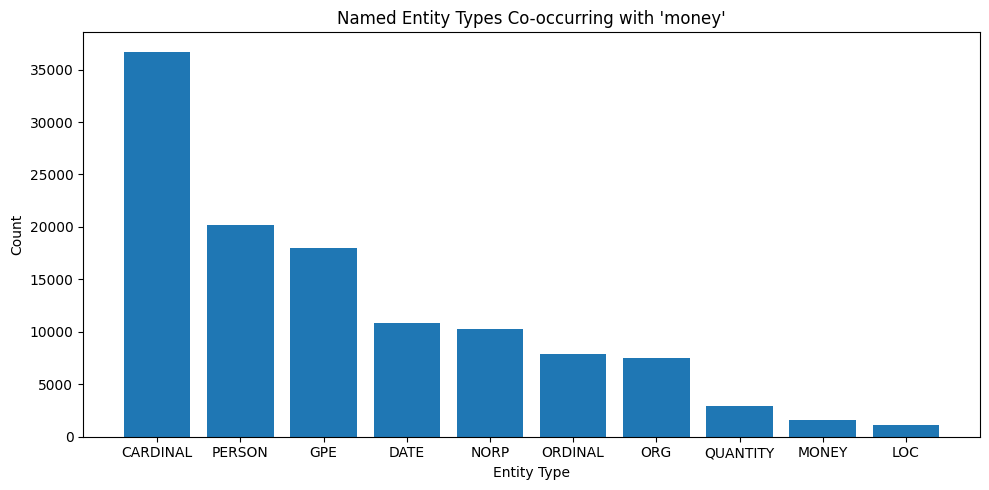

In [103]:
# Chart 1: Top entity labels
top_entities = entity_counter.most_common(10)

labels = [item[0] for item in top_entities]
counts = [item[1] for item in top_entities]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.title("Named Entity Types Co-occurring with 'money'")
plt.tight_layout()
plt.savefig(NER_CHART)
plt.show()

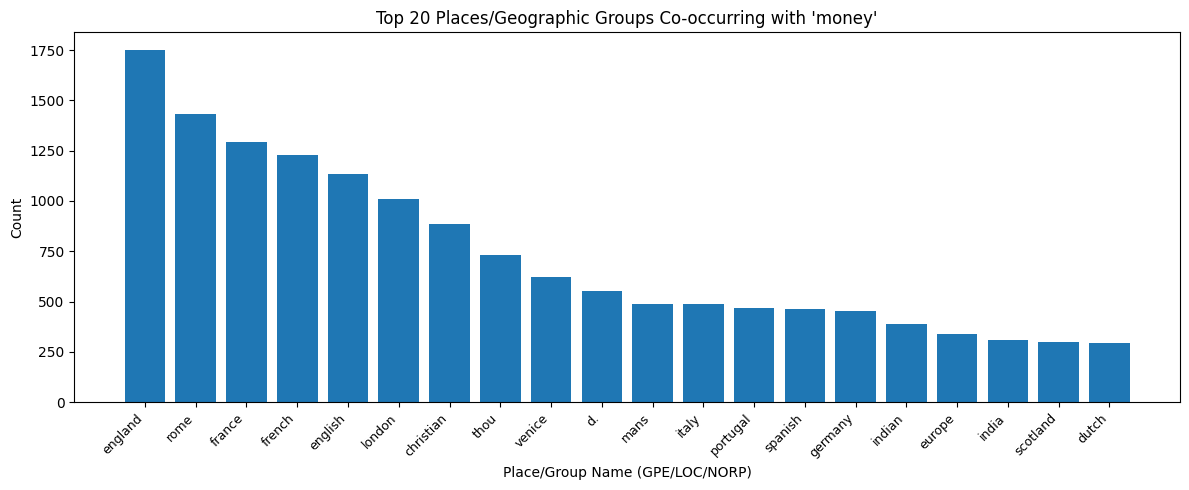

In [ ]:
# Chart 2: Top GPE / LOC / NORP entities
top_places = place_counter.most_common(20)

place_names = [item[0] for item in top_places]
place_vals = [item[1] for item in top_places]

plt.figure(figsize=(12, 5))
plt.bar(place_names, place_vals)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.xlabel("Place/Group Name (GPE/LOC/NORP)")
plt.ylabel("Count")
plt.title("Top 20 Places/Geographic Groups Co-occurring with 'money'")
plt.tight_layout()
plt.savefig(GPE_CHART)
plt.show()

In [108]:
# Load NER results
df2 = pd.read_csv("outputs/money_ner_results.csv")

all_entities = []

for _, row in df2.iterrows():
    if pd.isna(row["entities"]):
        continue

    parts = str(row["entities"]).split(" | ")

    for part in parts:
        match = re.match(r"^(.+)\s+\[([A-Z_]+)\]$", part.strip())

        if match:
            text = match.group(1).strip().lower()
            label = match.group(2)

            all_entities.append(
                {
                    "text": text,
                    "label": label,
                    "doc_id": row["doc_id"],
                    "matched_word": row["matched_word"],
                    "sentence_window": row["sentence_window"],
                }
            )

ent_df = pd.DataFrame(all_entities)

#### 4. Contextual Meaning with BERT 

In [137]:
# setting up files
BERT_OUTPUT = OUTPUTS / "money_bert_clusters.csv"
BERT_PLOT = OUTPUTS / "money_bert_pcaclusters.png"

# Settings
N_CLUSTERS = 3

In [112]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25588.35it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Note

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [134]:
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Working with {len(df_sample)} sampled sentences.")


def money_embedding(sentence):
    sentence = str(sentence)[:400]

    inputs = tokenizer(
        sentence, return_tensors="pt", truncation=True, max_length=128, padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.last_hidden_state[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    for i in range(len(tokens)):
        span = "".join(tokens[i : i + 3]).replace("##", "").lower()

        if span.startswith(("money", "monies", "moneys", "mony")):
            return hidden_states[i].numpy()

    return hidden_states[0].numpy()

Working with 5000 sampled sentences.


In [129]:
# generating BERT embeddings
print("\nGenerating BERT embeddings...")

embeddings = []

for i, row in df_sample.iterrows():
    emb = money_embedding(row["sentence_window"])
    embeddings.append(emb)

    if i % 100 == 0:
        print(f"{i}/{len(df_sample)} done...")

embeddings = np.array(embeddings)
embeddings = normalize(embeddings)

print(f"Embeddings shape: {embeddings.shape}")


Generating BERT embeddings...
0/5000 done...
100/5000 done...
200/5000 done...
300/5000 done...
400/5000 done...
500/5000 done...
600/5000 done...
700/5000 done...
800/5000 done...
900/5000 done...
1000/5000 done...
1100/5000 done...
1200/5000 done...
1300/5000 done...
1400/5000 done...
1500/5000 done...
1600/5000 done...
1700/5000 done...
1800/5000 done...
1900/5000 done...
2000/5000 done...
2100/5000 done...
2200/5000 done...
2300/5000 done...
2400/5000 done...
2500/5000 done...
2600/5000 done...
2700/5000 done...
2800/5000 done...
2900/5000 done...
3000/5000 done...
3100/5000 done...
3200/5000 done...
3300/5000 done...
3400/5000 done...
3500/5000 done...
3600/5000 done...
3700/5000 done...
3800/5000 done...
3900/5000 done...
4000/5000 done...
4100/5000 done...
4200/5000 done...
4300/5000 done...
4400/5000 done...
4500/5000 done...
4600/5000 done...
4700/5000 done...
4800/5000 done...
4900/5000 done...
Embeddings shape: (5000, 768)


In [138]:
# 2. K-means clustering
print("\nRunning K-means clustering...")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

df_sample["cluster"] = labels

print("\nCluster sizes:")
print(df_sample["cluster"].value_counts().sort_index())


Running K-means clustering...

Cluster sizes:
cluster
0     330
1    2834
2    1836
Name: count, dtype: int64



Running PCA for visualization...


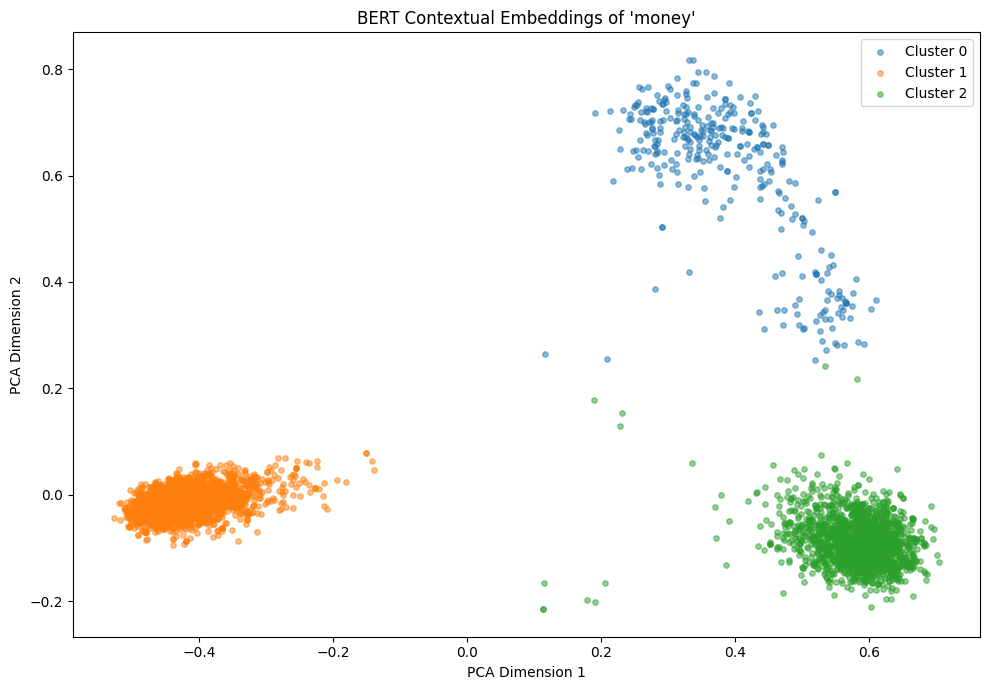

Plot saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_bert_pcaclusters.png


In [139]:
# 3. PCA visualization
print("\nRunning PCA for visualization...")

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

df_sample["pca_x"] = coords[:, 0]
df_sample["pca_y"] = coords[:, 1]

plt.figure(figsize=(10, 7))

for c in range(N_CLUSTERS):
    mask = df_sample["cluster"] == c
    plt.scatter(
        df_sample.loc[mask, "pca_x"],
        df_sample.loc[mask, "pca_y"],
        label=f"Cluster {c}",
        alpha=0.5,
        s=15,
    )

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.title("BERT Contextual Embeddings of 'money'")
plt.legend()
plt.tight_layout()
plt.savefig(BERT_PLOT, dpi=150)
plt.show()

print(f"Plot saved to: {BERT_PLOT}")

In [140]:
# 4. Inspect examples from each cluster
def inspect_cluster(cluster_id, n=10):
    print(f"\n{'=' * 70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'=' * 70}")

    subset = df_sample[df_sample["cluster"] == cluster_id]

    for _, row in subset.sample(min(n, len(subset)), random_state=42).iterrows():
        print(f"\nDoc ID: {row.get('doc_id', '')}")
        print(row["sentence_window"][:500])


inspect_cluster(0)
inspect_cluster(1)
inspect_cluster(2)


CLUSTER 0

Doc ID: A10821.txt
2. pecholi, and n the pound of grosses, it is the same in deniers, as i shewed before in the monies currant of the place. the exchanges made in venice, i have inserted in the 281. and 368. chapters, together with all circumstances thereto belonging, exchanges of . where by the way it is to bee noted, that in times past the good∣nesse of their monies both in payment for merchandise, and in pay∣ment for bills of exchange was alike and of equall goodnesse and value; but these wise senatours fearing

Doc ID: A07594__Circle_of_Commerce.txt
to the 3.§. 26. i reply, that although there wanted not takers of mony by exchange for hamburgh, when the exchange risse from 28 shillings to 35 shillings, yet it doth not follow, that therefore there would be takers at his par of exchange: for it is a plaine dispar, a different case. for those that then tooke mony for hamburgh, the takers gained and the deliuerers lost: because the exchange risse faster at hamburgh, by reas

In [141]:
# 5. Manually label clusters after inspection
# Change these labels after reading the sample examples above.

cluster_map = {0: "medium_exchange", 1: "consideration", 2: "unit_value"}

df_sample["cluster_label"] = df_sample["cluster"].map(cluster_map)

print("\nCluster label counts:")
print(df_sample["cluster_label"].value_counts())

# 6. Save final clustered data
CLUSTER_OUTPUT = OUTPUTS / "money_bert_clustered_results.csv"

df_sample.to_csv(CLUSTER_OUTPUT, index=False, encoding="utf-8")

print(f"\nClustered results saved to: {CLUSTER_OUTPUT}")
df_sample.head()


Cluster label counts:
cluster_label
consideration      2834
unit_value         1836
medium_exchange     330
Name: count, dtype: int64

Clustered results saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_bert_clustered_results.csv


,doc_id,matched_word,sentence_window,cluster,pca_x,pca_y,cluster_label
0,A11649.txt,money,"8. all the substance] or, all the riches (weal...",2,0.537881,-0.050996,unit_value
1,A07834.txt,moneys,"and the merchants there, for each zechine of g...",2,0.576061,-0.056045,unit_value
2,A16053.txt,money,the latter insisted to haue the keyes; the oth...,1,-0.396069,-0.004649,consideration
3,A16053.txt,money,"and i thought i did very wisely therein, lest ...",1,-0.453590,-0.055059,consideration
4,A12478.txt,money,"but here may a christian demand, quest. whethe...",2,0.611842,-0.120024,unit_value


In [119]:
# BERT clustering
print("\nClustering into 3 groups...")
N_CLUSTERS = 3
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = km.fit_predict(embeddings)
df_sample["cluster"] = labels


Clustering into 3 groups...


Running PCA for visualization...


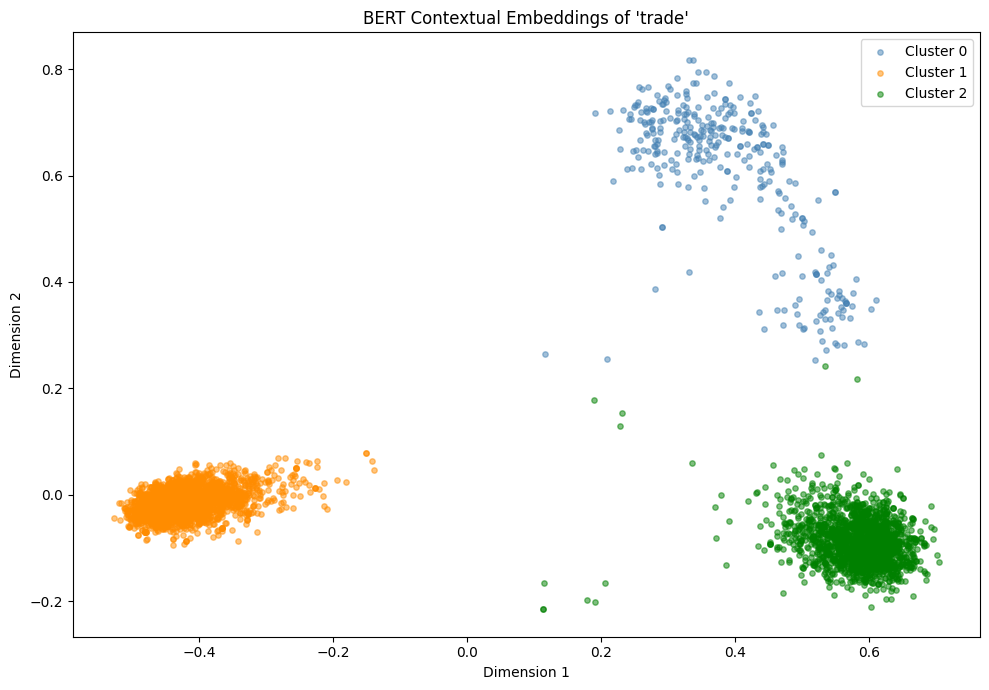

Plot saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_bert_pcaclusters.png


In [120]:
# PCA visualization
print("Running PCA for visualization...")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
df_sample["pca_x"] = coords[:, 0]
df_sample["pca_y"] = coords[:, 1]

colors = ["steelblue", "darkorange", "green", "red"]
plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = labels == c
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=f"Cluster {c}",
        alpha=0.5,
        s=15,
        color=colors[c],
    )
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("BERT Contextual Embeddings of 'trade'")
plt.legend()
plt.tight_layout()
plt.savefig(BERT_PLOT, dpi=150)
plt.show()
print(f"Plot saved to: {BERT_PLOT}")

In [ ]:
# representative samples per cluster
print("\n=== REPRESENTATIVE EXAMPLES PER CLUSTER ===")
for c in range(N_CLUSTERS):
    cluster_df = df_sample[df_sample["cluster"] == c]
    print(f"\n--- CLUSTER {c} ({len(cluster_df)} sentences) ---")
    for _, row in cluster_df.head(4).iterrows():
        print(f"  [{row['filename']}]")
        print(f"  {str(row['sentence'])[:200]}")
        print()

df_sample.to_csv(BERT_OUTPUT, index=False, encoding="utf-8")
print(f"Results saved to: {BERT_OUTPUT}")

#### 5. Supervised Classification (Logistic Regression)

In [150]:
print(OUTPUT_CSV)

/Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_occurrences.csv


In [ ]:
# setting up files
LR_OUTPUT = OUTPUTS / "money_classified.csv"
CM_OUTPUT = OUTPUTS / "money_cm.png"
COEF_OUTPUT = OUTPUTS / "money_top_features.png"

df3 = pd.read_csv(OUTPUT_CSV, encoding="utf-8")

CONSIDERATION_KEYWORDS = [
    r"\bpay\b",
    r"\bpayment\b",
    r"\bpaid\b",
    r"\bexchange\b",
    r"\bbill\b",
    r"\blen[dt]\b",
    r"\bborrow\b",
    r"\bbuy\b",
    r"\bsell\b",
    r"\brent\b",
    r"\bmerchant\b",
    r"\btrade\b",
]

VALUE_KEYWORDS = [
    r"\bvalue\b",
    r"\bprice of\b",
    r"\bvaluation\b",
    r"\bwealth\b",
    r"\btreasure\b",
    r"\bbullion\b",
    r"\bcoin\b",
    r"\bcoinage\b",
    r"\bmint\b",
    r"\bstandard\b",
    r"\bdenomination\b",
    r"\bdebas",
    r"\bdebasement\b",
    r"\bbalance of trade\b",
    r"\bnation\b",
    r"\bkingdom\b",
    r"\bstate\b",
    r"\bexchequer\b",
    r"\btreasury\b",
    r"\blaw\b.*\bmoney\b",
    r"\btransport\b",
    r"\bexport\b",
    r"\bimport\b",
]

In [158]:
# weak supervisor
def weak_label(sentence):
    s = str(sentence).lower()

    commercial_score = sum(1 for p in CONSIDERATION_KEYWORDS if re.search(p, s))
    state_score = sum(1 for p in VALUE_KEYWORDS if re.search(p, s))

    # Require stronger signal
    if state_score >= 1 and state_score > commercial_score:
        return 1  # state_money

    if commercial_score >= 1 and commercial_score > state_score:
        return 0  # commercial_money

    return -1

In [159]:
df["label"] = df["sentence_window"].apply(weak_label)

print("\n=== WEAK LABEL DISTRIBUTION ===")
print(df["label"].value_counts())

labeled = df[df["label"] != -1].copy()
print(f"\nUsable labeled sentences: {len(labeled)}")
print(f"  CONSIDERATION (0): {(labeled['label']==0).sum()}")
print(f"  VALUE (1): {(labeled['label']==1).sum()}")

print("\n=== SAMPLE LABELED SENTENCES ===")
print("\n-- CONSIDERATION (label=0) --")
for _, row in labeled[labeled["label"] == 0].head(4).iterrows():
    print(f"  {str(row['sentence_window'])[:200]}\n")

print("\n-- VALUE (label=1) --")
for _, row in labeled[labeled["label"] == 1].head(4).iterrows():
    print(f"  {str(row['sentence_window'])[:200]}\n")

print("\n=== TRAINING LOGISTIC REGRESSION ===")

X = labeled["sentence_window"].astype(str)
y = labeled["label"]


=== WEAK LABEL DISTRIBUTION ===
label
-1    7587
 0    4414
 1    3591
Name: count, dtype: int64

Usable labeled sentences: 8005
  CONSIDERATION (0): 4414
  VALUE (1): 3591

=== SAMPLE LABELED SENTENCES ===

-- CONSIDERATION (label=0) --
  hoe, whose within here? enter atlas a porter at. ha ye any mony to pay you knock with such authority sir? li. what if i haue not, may not a man knock without money sir?

  ha ye any mony to pay you knock with such authority sir? li. what if i haue not, may not a man knock without money sir? at. seldome, women and seriaunts they will not put it vp so sir.

  yes i thinke they are, would the scriuiner were paid for the making them. li. a shalbe so, though i doote my selfe, is the mony put vp as i appointed? ho. yes tis put vp, confusion cease the receiuers

  god; it chanced at last that their pouerty was soe great, as they had nothing to sustaine their life, nor defend them from the extremity of pouerty; at which the mother exceedingly afflicted, had

In [163]:
# vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), stop_words="english", min_df=2
)

X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {X_train.shape[0]} sentences, testing on {X_test.shape[0]}")

Training on 6404 sentences, testing on 1601


In [ ]:
# classification
clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\n=== CLASSIFICATION REPORT ===")
report_dict = classification_report(
    y_test, y_pred, target_names=["Consideration", "Value"], output_dict=True
)

print(classification_report(y_test, y_pred, target_names=["Consideration", "Value"]))

# convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# save to CSV
report_df.to_csv(OUTPUTS / "classification_report.csv")

print(f"\nSaved classification report to: {OUTPUTS / 'classification_report.csv'}")


=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Consideration       0.94      0.95      0.94       883
        Value       0.94      0.93      0.93       718

     accuracy                           0.94      1601
    macro avg       0.94      0.94      0.94      1601
 weighted avg       0.94      0.94      0.94      1601


Saved classification report to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/classification_report.csv


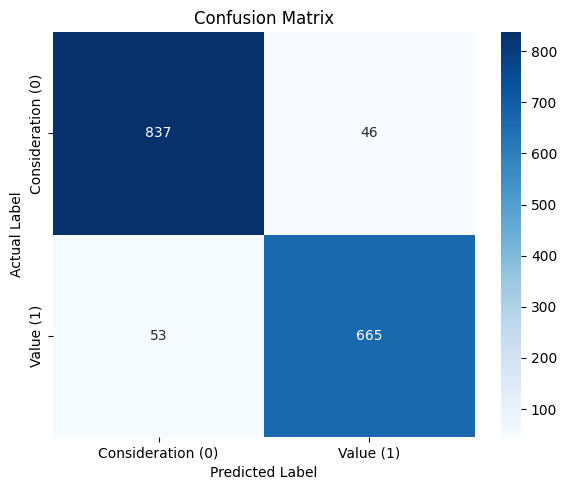

Confusion matrix saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_cm.png


In [169]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Consideration (0)", "Value (1)"],
    yticklabels=["Consideration (0)", "Value (1)"],
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig(CM_OUTPUT)
plt.show()

print(f"Confusion matrix saved to: {CM_OUTPUT}")


=== TOP FEATURES: CONSIDERATION ===
  pay                           : -10.588
  buy                           : -7.320
  sell                          : -6.624
  paid                          : -5.946
  merchant                      : -5.673
  payment                       : -4.681
  trade                         : -4.519
  exchange                      : -3.983
  lent                          : -3.547
  lend                          : -3.302
  rent                          : -2.915
  borrow                        : -2.708
  mony                          : -2.276
  soule                         : -1.709
  creditor                      : -1.654
  ship                          : -1.633
  clothes                       : -1.380
  london                        : -1.379
  summe                         : -1.369
  debt                          : -1.277

=== TOP FEATURES: VALUE ===
  state                         : 8.157
  value                         : 7.284
  wealth                        :

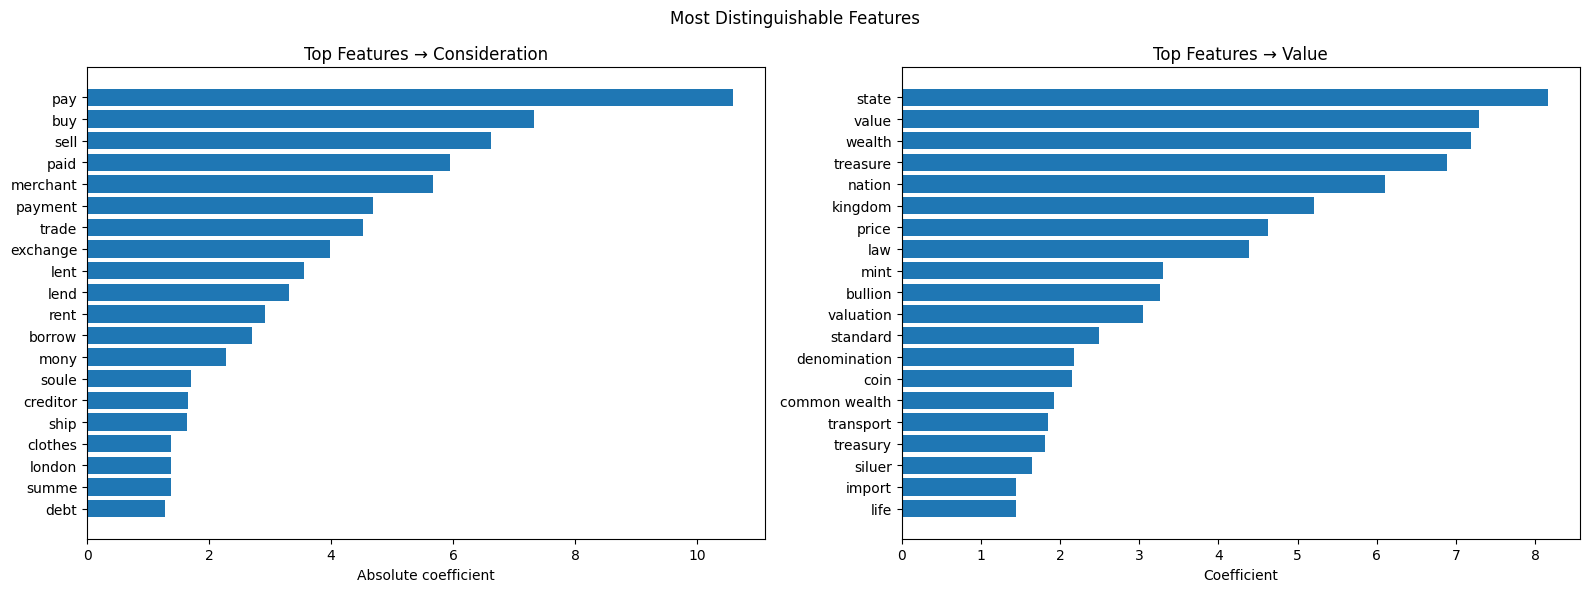

Feature chart saved to: /Users/varun/Documents/Duke-Astrid/Homework/term-project/outputs/money_top_features.png


In [ ]:
# top features
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top_n = 20

# For binary LogisticRegression:
# positive coefficients push toward class 1 = Value
# negative coefficients push toward class 0 = Consideration
top_value_idx = np.argsort(coefs)[::-1][:top_n]
top_consideration_idx = np.argsort(coefs)[:top_n]

top_value_words = [feature_names[i] for i in top_value_idx]
top_value_vals = [coefs[i] for i in top_value_idx]

top_consideration_words = [feature_names[i] for i in top_consideration_idx]
top_consideration_vals = [coefs[i] for i in top_consideration_idx]

print("\n=== TOP FEATURES: CONSIDERATION ===")
for w, v in zip(top_consideration_words, top_consideration_vals):
    print(f"  {w:30s}: {v:.3f}")

print("\n=== TOP FEATURES: VALUE ===")
for w, v in zip(top_value_words, top_value_vals):
    print(f"  {w:30s}: {v:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(top_consideration_words[::-1], [abs(v) for v in top_consideration_vals[::-1]])
ax1.set_title("Top Features → Consideration")
ax1.set_xlabel("Absolute coefficient")

ax2.barh(top_value_words[::-1], top_value_vals[::-1])
ax2.set_title("Top Features → Value")
ax2.set_xlabel("Coefficient")

plt.suptitle("Most Distinguishable Features")
plt.tight_layout()
plt.savefig(COEF_OUTPUT)
plt.show()

print(f"Feature chart saved to: {COEF_OUTPUT}")

In [ ]:
print("\n=== APPLYING MODEL TO FULL CORPUS ===")
unlabeled = df[df["label"] == -1].copy()
full_tfidf = vectorizer.transform(df["sentence"].astype(str))
df["predicted_label"] = clf.predict(full_tfidf)
df["predicted_label_name"] = df["predicted_label"].map(
    {0: "Policy/Commerce", 1: "Occupation/Craft"}
)

print("\nFull corpus predicted distribution:")
print(df["predicted_label_name"].value_counts())

df.to_csv(LR_OUTPUT, index=False, encoding="utf-8")
print(f"\nFull results saved to: {LR_OUTPUT}")